In [1]:
# If needed:
# !pip install -q optuna scikit-learn

In [2]:
from __future__ import annotations

import math
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())


Device: cuda
CUDA available: True


In [3]:
# ---------------------------
# CONFIG
# ---------------------------
# TRAIN_CSV = Path("../Splitting/train_split.csv")
# VAL_CSV   = Path("../Splitting/val_split.csv")
# TEST_CSV  = Path("../Splitting/test_split.csv")
TRAIN_CSV = Path("../Splitting/train_split_balanced.csv")
VAL_CSV   = Path("../Splitting/val_split_balanced.csv")
TEST_CSV  = Path("../Splitting/test_split_balanced.csv")


OUTPUT_DIR = Path("out/custom_cnn_optuna")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_DIR / "best_custom_cnn.pt"

NUM_CLASSES = 2
IMG_SIZE = 224
NUM_WORKERS = 0

N_TRIALS = 8
TUNING_EPOCHS = 10
FINAL_EPOCHS = 27
EARLY_STOPPING_PATIENCE = 10

USE_WEIGHTED_SAMPLER = True
USE_CLASS_WEIGHTED_LOSS = False

print(TRAIN_CSV, VAL_CSV, TEST_CSV)


..\Splitting\train_split_balanced.csv ..\Splitting\val_split_balanced.csv ..\Splitting\test_split_balanced.csv


In [4]:
# ---------------------------
# PATH HELPERS
# ---------------------------
# def normalize_image_path(p: str) -> str:
#     # convert windows-style separators safely for current OS
#     p = str(p).strip()
#     p = p.replace("\\", "/")
#     return str(Path(p))
BASE_DIR = Path("C:/Users/tahmi/OneDrive/Desktop/4-2/Thesis/Thesis_Coding_revised/Preprocessing_2/")
def normalize_image_path(p: str) -> str:
    p = str(p).strip()
    p = p.replace("\\", "/")

    p = Path(p)

    # If already absolute → keep it
    if p.is_absolute():
        return str(p)

    # Otherwise → attach base directory
    return str(BASE_DIR / p)

def load_split_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing split CSV: {path}")
    df = pd.read_csv(path)

    required_cols = ["image_id", "image_path", "target_class_id"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing required columns: {missing}")

    if "processing_status" in df.columns:
        df = df[df["processing_status"] == "ok"].copy()

    df = df[df["image_path"].notna()].copy()
    df["image_path"] = df["image_path"].astype(str).map(normalize_image_path)
    df["target_class_id"] = df["target_class_id"].astype(int)

    # filter missing files before training
    exists_mask = df["image_path"].map(lambda x: Path(x).exists())
    missing_df = df.loc[~exists_mask, ["image_id", "image_path"]].copy()

    print(f"\n{path.name}")
    print("Rows before file check:", len(df))
    print("Missing image files:", len(missing_df))
    if len(missing_df):
        display(missing_df.head(10))

    df = df.loc[exists_mask].reset_index(drop=True)
    print("Rows after file check:", len(df))

    return df

train_df = load_split_csv(TRAIN_CSV)
val_df   = load_split_csv(VAL_CSV)
test_df  = load_split_csv(TEST_CSV)

if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
    raise ValueError("One of the splits is empty after filtering missing image files.")

print("\nTrain target counts:")
print(train_df["target_class_id"].value_counts().sort_index())
print("\nVal target counts:")
print(val_df["target_class_id"].value_counts().sort_index())
print("\nTest target counts:")
print(test_df["target_class_id"].value_counts().sort_index())



train_split_balanced.csv
Rows before file check: 1246
Missing image files: 0
Rows after file check: 1246

val_split_balanced.csv
Rows before file check: 320
Missing image files: 0
Rows after file check: 320

test_split_balanced.csv
Rows before file check: 374
Missing image files: 0
Rows after file check: 374

Train target counts:
target_class_id
0    623
1    623
Name: count, dtype: int64

Val target counts:
target_class_id
0    160
1    160
Name: count, dtype: int64

Test target counts:
target_class_id
0    187
1    187
Name: count, dtype: int64


In [5]:
# ---------------------------
# DATASET
# ---------------------------
class NpyLungDataset(Dataset):
    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _augment_image(self, img: np.ndarray) -> np.ndarray:
        import cv2

        if np.random.rand() < 0.5:
            img = np.fliplr(img).copy()

        if np.random.rand() < 0.5:
            angle = np.random.uniform(-10, 10)
            center = (img.shape[1] / 2, img.shape[0] / 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            img = cv2.warpAffine(
                img,
                M,
                (img.shape[1], img.shape[0]),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REFLECT_101
            )

        if np.random.rand() < 0.3:
            noise = np.random.normal(0, 0.01, size=img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

        return img.astype(np.float32)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        label = int(row["target_class_id"])

        img_path = Path(image_path)
        if not img_path.exists():
            raise FileNotFoundError(f"Missing image file during loading: {img_path}")

        img = np.load(img_path).astype(np.float32)

        if img.shape != (IMG_SIZE, IMG_SIZE):
            raise ValueError(f"Unexpected image shape {img.shape} in {image_path}")

        if img.max() > 1.0 or img.min() < 0.0:
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)

        if self.augment:
            img = self._augment_image(img)

        img = np.expand_dims(img, axis=0)
        img = torch.tensor(img, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return {
            "image": img,
            "label": label,
            "image_id": row["image_id"],
            "image_path": image_path,
        }


In [6]:
# ---------------------------
# DATALOADERS
# ---------------------------
def make_sampler(df: pd.DataFrame):
    class_counts = df["target_class_id"].value_counts().to_dict()
    weights = df["target_class_id"].map(lambda x: 1.0 / class_counts[x]).values
    weights = torch.DoubleTensor(weights)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_dataset = NpyLungDataset(train_df, augment=True)
val_dataset   = NpyLungDataset(val_df, augment=False)
test_dataset  = NpyLungDataset(test_df, augment=False)

def make_loaders(batch_size: int):
    if USE_WEIGHTED_SAMPLER:
        sampler = make_sampler(train_df)
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader, test_loader


In [7]:
# ---------------------------
# MODEL (Grad-CAM ready)
# ---------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, dropout: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)



class CustomBaselineCNN(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3, fc_dim=128, num_classes=2):
        super().__init__()

        c1, c2, c3, c4 = channels
        self.features = nn.Sequential(
            ConvBlock(1, c1, dropout),
            ConvBlock(c1, c2, dropout),
            ConvBlock(c2, c3, dropout),
            ConvBlock(c3, c4, dropout),
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) #pooling used for grad cam, may not be needed in Integrated gradients
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c4, fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

    # def get_last_conv_layer(self):
    #     return self.features[-1].block[3]
    def get_last_conv_layer(self):
        return self.features[-1].block[5]
    


model = CustomBaselineCNN().to(device)
dummy = torch.randn(2, 1, 224, 224).to(device)
out = model(dummy)
print("Output shape:", out.shape)
print("Last conv layer:", model.get_last_conv_layer())


# class ConvBlockSingle(nn.Module):
#     def __init__(self, in_ch: int, out_ch: int, dropout: float):
#         super().__init__()
#         self.block = nn.Sequential(
#             nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(2),
#             nn.Dropout2d(dropout),
#         )

#     def forward(self, x):
#         return self.block(x)


# class CustomBaselineCNN(nn.Module):
#     def __init__(self, channels=(32, 64, 128, 256), dropout=0.3, fc_dim=128, num_classes=2):
#         super().__init__()

#         c1, c2, c3, c4 = channels
#         self.features = nn.Sequential(
#         ConvBlockSingle(1, c1, dropout),
#         ConvBlockSingle(c1, c2, dropout),
#         ConvBlockSingle(c2, c3, dropout),
#         ConvBlockSingle(c3, c4, dropout),
#         )

#         self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) #pooling used for grad cam, may not be needed in Integrated gradients
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(c4, fc_dim),
#             nn.ReLU(inplace=True),
#             nn.Dropout(dropout),
#             nn.Linear(fc_dim, num_classes),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.global_pool(x)
#         x = self.classifier(x)
#         return x

#     # def get_last_conv_layer(self):
#     #     return self.features[-1].block[3]
#     def get_last_conv_layer(self):
#         return self.features[-1].block[0]
    


# model = CustomBaselineCNN().to(device)
# dummy = torch.randn(2, 1, 224, 224).to(device)
# out = model(dummy)
# print("Output shape:", out.shape)
# print("Last conv layer:", model.get_last_conv_layer())


Output shape: torch.Size([2, 2])
Last conv layer: ReLU(inplace=True)


In [8]:
# ---------------------------
# TRAINING / EVAL HELPERS
# ---------------------------
def get_class_weights(df: pd.DataFrame):
    counts = df["target_class_id"].value_counts().sort_index()
    total = counts.sum()
    weights = total / (len(counts) * counts.values)
    return torch.tensor(weights, dtype=torch.float32, device=device)

@dataclass
class EpochResult:
    loss: float
    y_true: list
    y_pred: list
    y_prob: list

def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            if torch.cuda.is_available():
                with torch.amp.autocast("cuda", enabled=True):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                if scaler is not None and torch.cuda.is_available():
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    return EpochResult(loss=epoch_loss, y_true=y_true, y_pred=y_pred, y_prob=y_prob)


def compute_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    try:
        metrics["auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics["auc"] = float("nan")
    return metrics


In [9]:
# ---------------------------
# OPTUNA OBJECTIVE
# ---------------------------
def objective(trial):
    # batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    batch_size = trial.suggest_categorical("batch_size", [8, 16,32])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    fc_dim = trial.suggest_categorical("fc_dim", [64, 128, 256])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "adamw"])
    c1 = trial.suggest_categorical("c1", [16, 32])
    c2 = trial.suggest_categorical("c2", [32, 64])
    c3 = trial.suggest_categorical("c3", [64, 128])
    c4 = trial.suggest_categorical("c4", [128, 256])

    channels = sorted([c1, c2, c3, c4])

    train_loader, val_loader, _ = make_loaders(batch_size)

    model = CustomBaselineCNN(
        channels=tuple(channels),
        dropout=dropout,
        fc_dim=fc_dim,
        num_classes=NUM_CLASSES
    ).to(device)

    if USE_CLASS_WEIGHTED_LOSS:
        class_weights = get_class_weights(train_df)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    best_val_auc = -1.0
    epochs_no_improve = 0

    for epoch in range(TUNING_EPOCHS):
        train_res = run_one_epoch(model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
        val_res = run_one_epoch(model, val_loader, criterion, optimizer=None, scaler=None)

        val_metrics = compute_metrics(val_res.y_true, val_res.y_pred, val_res.y_prob)
        val_auc = val_metrics["auc"]

        scheduler.step(val_auc if not math.isnan(val_auc) else 0.0)

        trial.report(val_auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            break

    return best_val_auc


In [10]:
# ---------------------------
# RUN OPTUNA (IN MEMORY ONLY)
# ---------------------------
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
)

study.optimize(objective, n_trials=N_TRIALS)

print("Best trial:")
print("  Value:", study.best_trial.value)
print("  Params:")
for k, v in study.best_trial.params.items():
    print(f"    {k}: {v}")


[I 2026-04-19 21:23:13,466] A new study created in memory with name: no-name-378dcb8c-a675-4da6-a20b-5ddf15b9c0d7
[I 2026-04-19 21:24:18,544] Trial 0 finished with value: 0.8425976562499999 and parameters: {'batch_size': 16, 'lr': 0.0023224020844756525, 'weight_decay': 3.367293332017467e-06, 'dropout': 0.3244213363081896, 'fc_dim': 256, 'optimizer': 'adam', 'c1': 16, 'c2': 32, 'c3': 128, 'c4': 256}. Best is trial 0 with value: 0.8425976562499999.
[I 2026-04-19 21:25:16,513] Trial 1 finished with value: 0.8932226562500001 and parameters: {'batch_size': 32, 'lr': 0.00040011371639640564, 'weight_decay': 7.976449792417519e-05, 'dropout': 0.2718315863756053, 'fc_dim': 256, 'optimizer': 'adamw', 'c1': 32, 'c2': 64, 'c3': 64, 'c4': 256}. Best is trial 1 with value: 0.8932226562500001.
[I 2026-04-19 21:26:12,179] Trial 2 finished with value: 0.8360937500000001 and parameters: {'batch_size': 8, 'lr': 0.0001194431330538302, 'weight_decay': 1.0860033059989874e-06, 'dropout': 0.3229685627147391, '

Best trial:
  Value: 0.8932226562500001
  Params:
    batch_size: 32
    lr: 0.00040011371639640564
    weight_decay: 7.976449792417519e-05
    dropout: 0.2718315863756053
    fc_dim: 256
    optimizer: adamw
    c1: 32
    c2: 64
    c3: 64
    c4: 256


In [11]:
# ---------------------------
# TRAIN FINAL MODEL WITH BEST PARAMS
# ---------------------------
best_params = study.best_trial.params
best_channels = sorted([
    best_params["c1"], best_params["c2"], best_params["c3"], best_params["c4"]
])

best_model = CustomBaselineCNN(
    channels=tuple(best_channels),
    dropout=best_params["dropout"],
    fc_dim=best_params["fc_dim"],
    num_classes=NUM_CLASSES
).to(device)

batch_size = best_params["batch_size"]
train_loader, val_loader, test_loader = make_loaders(batch_size)

if USE_CLASS_WEIGHTED_LOSS:
    class_weights = get_class_weights(train_df)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

if best_params["optimizer"] == "adam":
    optimizer = optim.Adam(best_model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
else:
    optimizer = optim.AdamW(best_model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": [],
    "train_acc": [],
    "val_acc": [],
}

best_val_auc = -1.0
best_epoch = -1
epochs_no_improve = 0

for epoch in range(1, FINAL_EPOCHS + 1):
    train_res = run_one_epoch(best_model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
    val_res = run_one_epoch(best_model, val_loader, criterion, optimizer=None, scaler=None)

    train_metrics = compute_metrics(train_res.y_true, train_res.y_pred, train_res.y_prob)
    val_metrics = compute_metrics(val_res.y_true, val_res.y_pred, val_res.y_prob)

    history["train_loss"].append(train_res.loss)
    history["val_loss"].append(val_res.loss)
    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])

    scheduler.step(val_metrics["auc"] if not math.isnan(val_metrics["auc"]) else 0.0)

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": best_model.state_dict(),
                "best_params": best_params,
                "best_epoch": best_epoch,
                "best_val_auc": best_val_auc,
                "channels": tuple(best_channels),
            },
            BEST_MODEL_PATH
        )
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:02d}/{FINAL_EPOCHS} | "
        f"Train Loss: {train_res.loss:.4f} | Val Loss: {val_res.loss:.4f} | "
        f"Train AUC: {train_metrics['auc']:.4f} | Val AUC: {val_metrics['auc']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}"
    )

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

print("\nBest epoch:", best_epoch)
print("Best val AUC:", best_val_auc)
print("Saved best model to:", BEST_MODEL_PATH)


Epoch 01/27 | Train Loss: 0.5949 | Val Loss: 0.9136 | Train AUC: 0.7415 | Val AUC: 0.8087 | Train Acc: 0.6822 | Val Acc: 0.5000
Epoch 02/27 | Train Loss: 0.5257 | Val Loss: 0.4987 | Train AUC: 0.7907 | Val AUC: 0.8049 | Train Acc: 0.7215 | Val Acc: 0.7188
Epoch 03/27 | Train Loss: 0.5158 | Val Loss: 0.5349 | Train AUC: 0.8001 | Val AUC: 0.8010 | Train Acc: 0.7311 | Val Acc: 0.6687
Epoch 04/27 | Train Loss: 0.5035 | Val Loss: 0.5050 | Train AUC: 0.8013 | Val AUC: 0.8036 | Train Acc: 0.7303 | Val Acc: 0.7219
Epoch 05/27 | Train Loss: 0.4948 | Val Loss: 0.4595 | Train AUC: 0.8052 | Val AUC: 0.8362 | Train Acc: 0.7440 | Val Acc: 0.7688
Epoch 06/27 | Train Loss: 0.4914 | Val Loss: 0.4559 | Train AUC: 0.8067 | Val AUC: 0.8367 | Train Acc: 0.7368 | Val Acc: 0.7750
Epoch 07/27 | Train Loss: 0.5026 | Val Loss: 0.4450 | Train AUC: 0.8020 | Val AUC: 0.8495 | Train Acc: 0.7327 | Val Acc: 0.8063
Epoch 08/27 | Train Loss: 0.4834 | Val Loss: 0.4669 | Train AUC: 0.8265 | Val AUC: 0.8447 | Train Acc: 0

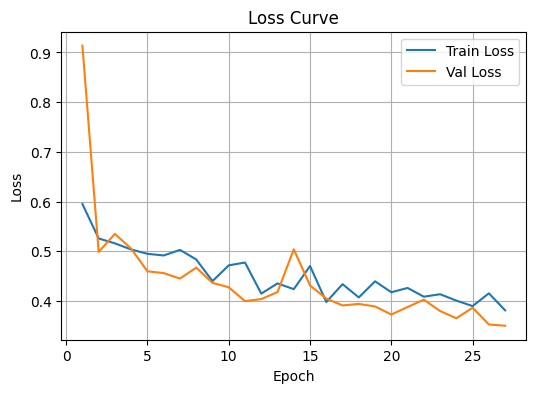

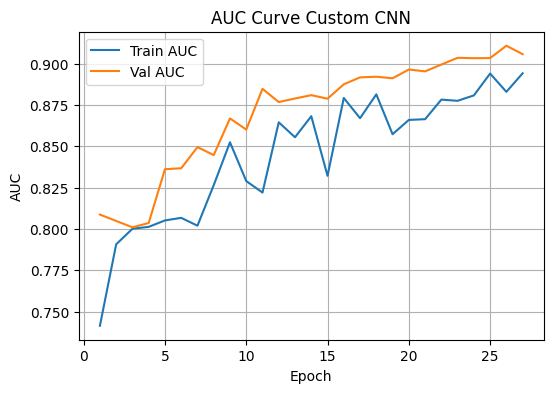

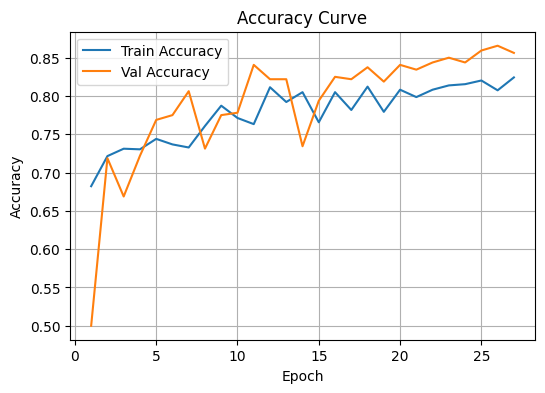

In [12]:
# ---------------------------
# PLOTS
# ---------------------------
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_auc"], label="Train AUC")
plt.plot(epochs, history["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("AUC Curve Custom CNN")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# # ---------------------------
# # LOAD BEST MODEL AND TEST
# # ---------------------------
# ckpt = torch.load(BEST_MODEL_PATH, map_location=device)

# best_model = CustomBaselineCNN(
#     channels=tuple(ckpt["channels"]),
#     dropout=best_params["dropout"],
#     fc_dim=best_params["fc_dim"],
#     num_classes=NUM_CLASSES
# ).to(device)
# best_model.load_state_dict(ckpt["model_state_dict"])
# best_model.eval()

# test_res = run_one_epoch(best_model, test_loader, criterion, optimizer=None, scaler=None)
# test_metrics = compute_metrics(test_res.y_true, test_res.y_pred, test_res.y_prob)

# print("Test metrics:")
# for k, v in test_metrics.items():
#     print(f"{k}: {v:.4f}")

# print("\nClassification report:")
# print(classification_report(test_res.y_true, test_res.y_pred, target_names=["benign", "malignant"], zero_division=0))
# ---------------------------
# LOAD BEST MODEL AND TEST
# ---------------------------
ckpt = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)

best_model = CustomBaselineCNN(
    channels=tuple(ckpt["channels"]),
    dropout=ckpt["best_params"]["dropout"],
    fc_dim=ckpt["best_params"]["fc_dim"],
    num_classes=NUM_CLASSES
).to(device)

best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()

test_res = run_one_epoch(best_model, test_loader, criterion, optimizer=None, scaler=None)
test_metrics = compute_metrics(test_res.y_true, test_res.y_pred, test_res.y_prob)

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

print("\\nClassification report:")
print(
    classification_report(
        test_res.y_true,
        test_res.y_pred,
        target_names=["benign", "malignant"],
        zero_division=0
    )
)
# train_res = run_one_epoch(best_model, train_loader, criterion, optimizer=None, scaler=None)
# train_metrics = compute_metrics(train_res.y_true, train_res.y_pred, train_res.y_prob)

# print("Train metrics:")
# for k, v in train_metrics.items():
#     print(f"{k}: {v:.4f}")

# print("\nClassification report on train set:")
# print(
#     classification_report(
#         train_res.y_true,
#         train_res.y_pred,
#         target_names=["benign", "malignant"],
#         zero_division=0
#     )
# )

Test metrics:
accuracy: 0.8476
precision: 0.7826
recall: 0.9626
f1: 0.8633
auc: 0.8882
\nClassification report:
              precision    recall  f1-score   support

      benign       0.95      0.73      0.83       187
   malignant       0.78      0.96      0.86       187

    accuracy                           0.85       374
   macro avg       0.87      0.85      0.85       374
weighted avg       0.87      0.85      0.85       374



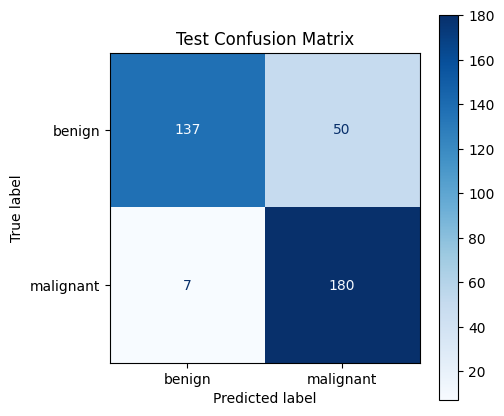

In [14]:
# ---------------------------
# CONFUSION MATRIX
# ---------------------------
cm = confusion_matrix(test_res.y_true, test_res.y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "malignant"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax,cmap='Blues')
plt.title("Test Confusion Matrix")
plt.show()


In [15]:
# ---------------------------
# SAVE PREDICTIONS
# ---------------------------
test_pred_df = test_df.copy()
test_pred_df["y_true"] = test_res.y_true
test_pred_df["y_pred"] = test_res.y_pred
test_pred_df["y_prob_malignant"] = test_res.y_prob

pred_csv = OUTPUT_DIR / "test_predictions.csv"
test_pred_df.to_csv(pred_csv, index=False)
print("Saved test predictions to:", pred_csv)
test_pred_df.head()


Saved test predictions to: out\custom_cnn_optuna\test_predictions.csv


,image_id,patient_id,slice_index,z_position,sample_type,target_class,target_class_id,malignancy_avg,class_id,has_nodule,...,resampled_width,hu_min,hu_max,normalization,num_consensus_nodules_original,num_consensus_nodules_in_crop,malignancy_max,y_true,y_pred,y_prob_malignant
0,LIDC-IDRI-0023__slice_0120__aug_tx_+36_ty_-38,LIDC-IDRI-0023,120,-75.750000,pos,malignant,1,4.75,1,1,...,380,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0,1,1,0.786133
1,LIDC-IDRI-0977__slice_0020,LIDC-IDRI-0977,20,-250.949997,neg,benign,0,NaN,0,0,...,300,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",0,0,NaN,0,0,0.020157
2,LIDC-IDRI-0783__slice_0020,LIDC-IDRI-0783,20,-321.000000,neg,benign,0,NaN,0,0,...,360,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",0,0,NaN,0,0,0.010529
3,LIDC-IDRI-0749__slice_0074__aug_tx_-38_ty_+36,LIDC-IDRI-0749,74,206.500000,pos,malignant,1,4.25,1,1,...,322,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",1,1,5.0,1,1,0.867676
4,LIDC-IDRI-0007__slice_0033,LIDC-IDRI-0007,33,-277.000000,hard_neg,benign,0,NaN,0,0,...,400,-700.0,200.0,"minmax_after_hu_window_to_[0,1]",0,0,NaN,0,0,0.171265


In [16]:
# ---------------------------
# XAI READINESS CHECK
# ---------------------------
print("Last conv layer for Grad-CAM / Grad-CAM++:")
print(best_model.get_last_conv_layer())


Last conv layer for Grad-CAM / Grad-CAM++:
ReLU(inplace=True)


In [17]:
# ---------------------------
# OPTIONAL: Inspect one batch
# ---------------------------
batch = next(iter(train_loader))
print("Image batch shape:", batch["image"].shape)
print("Label batch shape:", batch["label"].shape)
print("Example image_ids:", batch["image_id"][:5])


Image batch shape: torch.Size([32, 1, 224, 224])
Label batch shape: torch.Size([32])
Example image_ids: ['LIDC-IDRI-0890__slice_0020', 'LIDC-IDRI-0185__slice_0113', 'LIDC-IDRI-0054__slice_0083', 'LIDC-IDRI-0261__slice_0020', 'LIDC-IDRI-0530__slice_0020']


In [18]:
# ---------------------------
# PATCH IN-PLACE RELU FOR GRAD-CAM
# ---------------------------
def disable_inplace_relu(module):
    for child_name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, child_name, nn.ReLU(inplace=False))
        else:
            disable_inplace_relu(child)

disable_inplace_relu(best_model)
best_model.eval()

print("All in-place ReLU layers changed to inplace=False for Grad-CAM.")

All in-place ReLU layers changed to inplace=False for Grad-CAM.


XAI CONFIG AND HELPERS

In [43]:
# ---------------------------
# XAI CONFIG + HELPERS
# ---------------------------
import cv2
from pathlib import Path
from sklearn.metrics import precision_score, recall_score

# Change this if your real mask column name is different
MASK_COL_CANDIDATES = ["mask_path", "mask_npy_path", "mask_png_path"]

# Grad-CAM settings
TARGET_CLASS = 1   # malignant class
#CAM_THRESHOLD_MODE = "percentile"   # "percentile" or "fixed"
CAM_THRESHOLD_MODE = "fixed"   # "percentile" or "fixed"

CAM_PERCENTILE = 95   # keep top 20% activated pixels
CAM_FIXED_THRESHOLD = 0.5

XAI_DIR = OUTPUT_DIR / "xai_gradcam"
XAI_DIR.mkdir(parents=True, exist_ok=True)

def find_mask_column(df: pd.DataFrame):
    for col in MASK_COL_CANDIDATES:
        if col in df.columns:
            return col
    return None

def normalize_mask_path(p: str) -> str:
    p = str(p).strip().replace("\\", "/")
    p = Path(p)
    if p.is_absolute():
        return str(p)
    return str(BASE_DIR / p)

def load_mask(mask_path: str, image_size: int = IMG_SIZE) -> np.ndarray:
    """
    Loads .npy or image mask and returns binary mask of shape (H, W).
    """
    mask_path = Path(mask_path)
    if not mask_path.exists():
        raise FileNotFoundError(f"Mask file not found: {mask_path}")

    if mask_path.suffix.lower() == ".npy":
        mask = np.load(mask_path)
    else:
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise ValueError(f"Could not load mask: {mask_path}")

    mask = np.asarray(mask)

    # if mask has extra channel dimension
    if mask.ndim == 3:
        mask = mask[..., 0]

    if mask.shape != (image_size, image_size):
        mask = cv2.resize(mask.astype(np.float32), (image_size, image_size), interpolation=cv2.INTER_NEAREST)

    # binarize
    mask = (mask > 0).astype(np.uint8)
    return mask

def dice_score(gt: np.ndarray, pred: np.ndarray, eps: float = 1e-8) -> float:
    intersection = np.logical_and(gt, pred).sum()
    return (2.0 * intersection) / (gt.sum() + pred.sum() + eps)

def iou_score(gt: np.ndarray, pred: np.ndarray, eps: float = 1e-8) -> float:
    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    return intersection / (union + eps)

def precision_recall_binary(gt: np.ndarray, pred: np.ndarray):
    gt_f = gt.flatten()
    pred_f = pred.flatten()
    prec = precision_score(gt_f, pred_f, zero_division=0)
    rec = recall_score(gt_f, pred_f, zero_division=0)
    return prec, rec

def binarize_cam(cam: np.ndarray,
                 mode: str = CAM_THRESHOLD_MODE,
                 percentile: float = CAM_PERCENTILE,
                 fixed_thresh: float = CAM_FIXED_THRESHOLD) -> np.ndarray:
    """
    cam is normalized [0,1]
    """
    if mode == "percentile":
        thresh = np.percentile(cam, percentile)
    elif mode == "fixed":
        thresh = fixed_thresh
    else:
        raise ValueError("mode must be 'percentile' or 'fixed'")
    print("Threshold:", thresh, "Max CAM:", cam.max())  # ✅ add this
    binary = (cam >= thresh).astype(np.uint8)
    return binary

def lesion_energy_ratio(cam: np.ndarray, gt_mask: np.ndarray, eps: float = 1e-8) -> float:
    """
    Fraction of total CAM energy that falls inside lesion mask.
    """
    return float((cam * gt_mask).sum() / (cam.sum() + eps))

def peak_hit(cam: np.ndarray, gt_mask: np.ndarray) -> int:
    """
    1 if max-activation pixel falls inside lesion, else 0
    """
    y, x = np.unravel_index(np.argmax(cam), cam.shape)
    return int(gt_mask[y, x] > 0)

In [44]:
# ---------------------------
# GRAD-CAM
# ---------------------------
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handles = []

        self.handles.append(
            self.target_layer.register_forward_hook(self._forward_hook)
        )
        self.handles.append(
            self.target_layer.register_full_backward_hook(self._backward_hook)
        )

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor: torch.Tensor, class_idx: int = None):
        """
        input_tensor shape: [1, 1, H, W]
        returns normalized cam in numpy shape (H, W)
        """
        self.model.eval()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())

        score = output[:, class_idx]
        self.model.zero_grad()
        score.backward(retain_graph=True)

        grads = self.gradients[0]        # [C, h, w]
        acts = self.activations[0]       # [C, h, w]

        weights = grads.mean(dim=(1, 2), keepdim=True)   # [C,1,1]
        cam = (weights * acts).sum(dim=0)                # [h,w]
        cam = torch.relu(cam)

        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        cam = cv2.GaussianBlur(cam, (7, 7), 0)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

    def remove_hooks(self):
        for h in self.handles:
            h.remove()

In [45]:
# ---------------------------
# GRAD-CAM++
# ---------------------------
class GradCAMPlusPlus:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handles = []

        self.handles.append(
            self.target_layer.register_forward_hook(self._forward_hook)
        )
        self.handles.append(
            self.target_layer.register_full_backward_hook(self._backward_hook)
        )

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor: torch.Tensor, class_idx: int = None):
        self.model.eval()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())

        score = output[:, class_idx]
        self.model.zero_grad()
        score.backward(retain_graph=True)

        grads = self.gradients[0]   # [C, H, W]
        acts  = self.activations[0] # [C, H, W]

        # Grad-CAM++ weights
        grads_power_2 = grads ** 2
        grads_power_3 = grads ** 3

        sum_acts = acts.view(acts.shape[0], -1).sum(dim=1, keepdim=True).view(-1,1,1)

        eps = 1e-8
        alpha = grads_power_2 / (2 * grads_power_2 + sum_acts * grads_power_3 + eps)

        weights = (alpha * torch.relu(grads)).sum(dim=(1,2), keepdim=True)

        cam = (weights * acts).sum(dim=0)
        cam = torch.relu(cam)

        cam = cam.detach().cpu().numpy()
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        cam = cv2.GaussianBlur(cam, (7, 7), 0)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

    def remove_hooks(self):
        for h in self.handles:
            h.remove()

In [46]:

# ---------------------------
# [IG CHANGE] INTEGRATED GRADIENTS
# Added independently after Grad-CAM / Grad-CAM++ without changing their code
# ---------------------------
try:
    from captum.attr import IntegratedGradients
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "captum", "-q"])
    from captum.attr import IntegratedGradients

class IntegratedGradientsExplainer:
    def __init__(self, model: nn.Module):
        self.model = model
        self.ig = IntegratedGradients(model)

    def generate(
        self,
        input_tensor: torch.Tensor,
        class_idx: int = None,
        baseline: torch.Tensor = None,
        steps: int = 50,
        internal_batch_size: int = None,
    ) -> np.ndarray:
        """
        Returns normalized positive attributions as a 2D numpy array in [0, 1].
        input_tensor shape: [1, 1, H, W]
        """
        self.model.eval()

        if class_idx is None:
            with torch.no_grad():
                logits = self.model(input_tensor)
                class_idx = int(logits.argmax(dim=1).item())

        if baseline is None:
            baseline = torch.zeros_like(input_tensor)

        attributions = self.ig.attribute(
            inputs=input_tensor,
            baselines=baseline,
            target=class_idx,
            n_steps=steps,
            internal_batch_size=internal_batch_size,
        )

        attr = attributions.detach().cpu().numpy()[0, 0]

        # Keep only positive relevance for localization-style evaluation
        attr = np.maximum(attr, 0)

        # Light smoothing to reduce pixel noise
        attr = cv2.GaussianBlur(attr.astype(np.float32), (7, 7), 0)

        # Normalize to [0, 1]
        attr = attr - attr.min()
        attr = attr / (attr.max() + 1e-8)

        return attr.astype(np.float32)

IG_STEPS = 50
IG_DIR = OUTPUT_DIR / "xai_integrated_gradients"
IG_DIR.mkdir(parents=True, exist_ok=True)
print("Integrated Gradients output directory:", IG_DIR)


Integrated Gradients output directory: out\custom_cnn_optuna\xai_integrated_gradients


In [47]:
# ---------------------------
# PREPARE TEST DATA FOR XAI
# ---------------------------
mask_col = find_mask_column(test_pred_df)

if mask_col is None:
    raise ValueError(
        f"No mask column found in test_pred_df. "
        f"Available columns: {list(test_pred_df.columns)}\n"
        f"Please add your mask path column and update MASK_COL_CANDIDATES."
    )

print("Using mask column:", mask_col)

xai_df = test_pred_df.copy()

# normalize mask paths only where present
xai_df[mask_col] = xai_df[mask_col].astype(str)
xai_df.loc[xai_df[mask_col].notna(), mask_col] = xai_df.loc[xai_df[mask_col].notna(), mask_col].map(normalize_mask_path)

# keep only rows that have masks
xai_df = xai_df[xai_df[mask_col].notna()].copy()
xai_df = xai_df[xai_df[mask_col].astype(str).str.strip() != ""].copy()

print("Rows with masks:", len(xai_df))

# Recommended: evaluate only true positive malignant images
xai_eval_df = xai_df[
    (xai_df["y_true"] == 1) &
    (xai_df["y_pred"] == 1)
].copy()

print("True positive malignant rows for XAI:", len(xai_eval_df))

# If you want all positive images with masks instead, use this:
# xai_eval_df = xai_df[xai_df["y_true"] == 1].copy()

Using mask column: mask_path
Rows with masks: 374
True positive malignant rows for XAI: 180


In [48]:
# ---------------------------
# RUN GRAD-CAM + QUANTITATIVE EVALUATION
# ---------------------------
gradcam = GradCAMPlusPlus(best_model, best_model.get_last_conv_layer())

results = []

for idx, row in xai_eval_df.iterrows():
    image_id = row["image_id"]
    image_path = Path(row["image_path"])
    mask_path = Path(row[mask_col])

    # load image
    img = np.load(image_path).astype(np.float32)

    if img.shape != (IMG_SIZE, IMG_SIZE):
        raise ValueError(f"Unexpected image shape {img.shape} for {image_id}")

    if img.max() > 1.0 or img.min() < 0.0:
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    input_tensor = torch.tensor(img[None, None, :, :], dtype=torch.float32, device=device)

    # generate CAM for malignant class
    cam = gradcam.generate(input_tensor, class_idx=TARGET_CLASS)

    # load GT mask
    gt_mask = load_mask(str(mask_path), image_size=IMG_SIZE)

    # binarize CAM
    cam_bin = binarize_cam(cam)

    # metrics
    dice = dice_score(gt_mask, cam_bin)
    iou = iou_score(gt_mask, cam_bin)
    prec, rec = precision_recall_binary(gt_mask, cam_bin)
    energy = lesion_energy_ratio(cam, gt_mask)
    hit = peak_hit(cam, gt_mask)

    results.append({
        "image_id": image_id,
        "image_path": str(image_path),
        "mask_path": str(mask_path),
        "y_true": int(row["y_true"]),
        "y_pred": int(row["y_pred"]),
        "y_prob_malignant": float(row["y_prob_malignant"]),
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(prec),
        "recall": float(rec),
        "lesion_energy_ratio": float(energy),
        "peak_hit": int(hit),
        "gt_mask_pixels": int(gt_mask.sum()),
        "cam_bin_pixels": int(cam_bin.sum()),
        "cam_max": float(cam.max()),
        "cam_mean": float(cam.mean()),
    })

gradcam.remove_hooks()

xai_results_df = pd.DataFrame(results)
xai_results_df.head()

Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max CAM: 1.0
Threshold: 0.5 Max C

,image_id,image_path,mask_path,y_true,y_pred,y_prob_malignant,dice,iou,precision,recall,lesion_energy_ratio,peak_hit,gt_mask_pixels,cam_bin_pixels,cam_max,cam_mean
0,LIDC-IDRI-0023__slice_0120__aug_tx_+36_ty_-38,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.786133,0.0,0.0,0.0,0.0,0.002030,0,525,5479,1.0,0.191331
1,LIDC-IDRI-0749__slice_0074__aug_tx_-38_ty_+36,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.867676,0.0,0.0,0.0,0.0,0.002640,0,310,3220,1.0,0.196221
2,LIDC-IDRI-0073__slice_0110__aug_tx_+36_ty_+36,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.825684,0.0,0.0,0.0,0.0,0.001162,0,307,5778,1.0,0.190403
3,LIDC-IDRI-0423__slice_0170__aug_tx_+36_ty_-38,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.789551,0.0,0.0,0.0,0.0,0.000202,0,403,8973,1.0,0.262124
4,LIDC-IDRI-0023__slice_0120,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.765625,0.0,0.0,0.0,0.0,0.001886,0,525,5055,1.0,0.184464


In [49]:

# ---------------------------
# [IG CHANGE] RUN INTEGRATED GRADIENTS + QUANTITATIVE EVALUATION
# Added as an independent block after Grad-CAM evaluation
# ---------------------------
ig_explainer = IntegratedGradientsExplainer(best_model)

ig_results = []

for idx, row in xai_eval_df.iterrows():
    image_id = row["image_id"]
    image_path = Path(row["image_path"])
    mask_path = Path(row[mask_col])

    # load image
    img = np.load(image_path).astype(np.float32)

    if img.shape != (IMG_SIZE, IMG_SIZE):
        raise ValueError(f"Unexpected image shape {img.shape} for {image_id}")

    if img.max() > 1.0 or img.min() < 0.0:
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    input_tensor = torch.tensor(img[None, None, :, :], dtype=torch.float32, device=device)
    baseline = torch.zeros_like(input_tensor)

    # generate Integrated Gradients attribution for malignant class
    ig_map = ig_explainer.generate(
        input_tensor=input_tensor,
        class_idx=TARGET_CLASS,
        baseline=baseline,
        steps=IG_STEPS,
    )

    # load GT mask
    gt_mask = load_mask(str(mask_path), image_size=IMG_SIZE)

    # binarize attribution map
    ig_bin = binarize_cam(ig_map)

    # metrics
    dice = dice_score(gt_mask, ig_bin)
    iou = iou_score(gt_mask, ig_bin)
    prec, rec = precision_recall_binary(gt_mask, ig_bin)
    energy = lesion_energy_ratio(ig_map, gt_mask)
    hit = peak_hit(ig_map, gt_mask)

    ig_results.append({
        "image_id": image_id,
        "image_path": str(image_path),
        "mask_path": str(mask_path),
        "y_true": int(row["y_true"]),
        "y_pred": int(row["y_pred"]),
        "y_prob_malignant": float(row["y_prob_malignant"]),
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(prec),
        "recall": float(rec),
        "lesion_energy_ratio": float(energy),
        "peak_hit": int(hit),
        "gt_mask_pixels": int(gt_mask.sum()),
        "ig_bin_pixels": int(ig_bin.sum()),
        "ig_max": float(ig_map.max()),
        "ig_mean": float(ig_map.mean()),
    })

ig_results_df = pd.DataFrame(ig_results)
ig_results_df.head()


Threshold: 0.5 Max CAM: 0.9999965
Threshold: 0.5 Max CAM: 0.999994
Threshold: 0.5 Max CAM: 0.99999654
Threshold: 0.5 Max CAM: 0.9999947
Threshold: 0.5 Max CAM: 0.9999965
Threshold: 0.5 Max CAM: 0.9999936
Threshold: 0.5 Max CAM: 0.9999922
Threshold: 0.5 Max CAM: 0.9999944
Threshold: 0.5 Max CAM: 0.9999948
Threshold: 0.5 Max CAM: 0.99999493
Threshold: 0.5 Max CAM: 0.9999931
Threshold: 0.5 Max CAM: 0.9999972
Threshold: 0.5 Max CAM: 0.9999967
Threshold: 0.5 Max CAM: 0.9999958
Threshold: 0.5 Max CAM: 0.99999726
Threshold: 0.5 Max CAM: 0.999997
Threshold: 0.5 Max CAM: 0.9999943
Threshold: 0.5 Max CAM: 0.9999952
Threshold: 0.5 Max CAM: 0.9999948
Threshold: 0.5 Max CAM: 0.999994
Threshold: 0.5 Max CAM: 0.9999923
Threshold: 0.5 Max CAM: 0.9999932
Threshold: 0.5 Max CAM: 0.9999955
Threshold: 0.5 Max CAM: 0.9999953
Threshold: 0.5 Max CAM: 0.99999225
Threshold: 0.5 Max CAM: 0.9999955
Threshold: 0.5 Max CAM: 0.9999945
Threshold: 0.5 Max CAM: 0.9999924
Threshold: 0.5 Max CAM: 0.99999624
Threshold: 0

,image_id,image_path,mask_path,y_true,y_pred,y_prob_malignant,dice,iou,precision,recall,lesion_energy_ratio,peak_hit,gt_mask_pixels,ig_bin_pixels,ig_max,ig_mean
0,LIDC-IDRI-0023__slice_0120__aug_tx_+36_ty_-38,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.786133,0.000000,0.000000,0.000000,0.000000,0.020395,0,525,62,0.999996,0.024950
1,LIDC-IDRI-0749__slice_0074__aug_tx_-38_ty_+36,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.867676,0.000000,0.000000,0.000000,0.000000,0.034447,0,310,55,0.999994,0.023198
2,LIDC-IDRI-0073__slice_0110__aug_tx_+36_ty_+36,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.825684,0.022923,0.011594,0.095238,0.013029,0.022164,0,307,42,0.999997,0.019284
3,LIDC-IDRI-0423__slice_0170__aug_tx_+36_ty_-38,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.789551,0.000000,0.000000,0.000000,0.000000,0.011093,0,403,26,0.999995,0.024452
4,LIDC-IDRI-0023__slice_0120,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,C:\Users\tahmi\OneDrive\Desktop\4-2\Thesis\The...,1,1,0.765625,0.000000,0.000000,0.000000,0.000000,0.015100,0,525,96,0.999996,0.026102


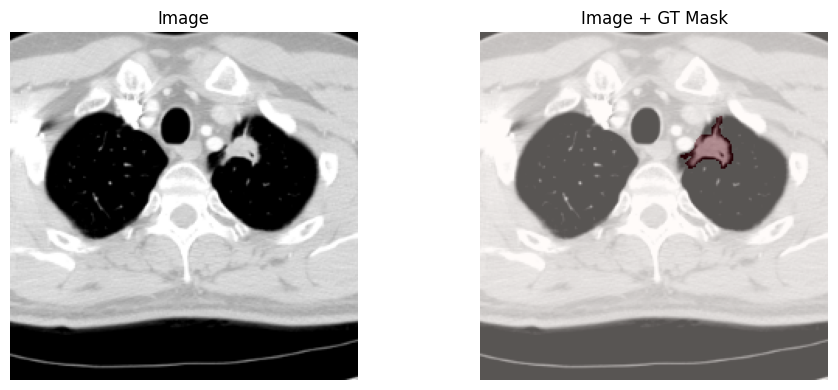

Image ID: LIDC-IDRI-0023__slice_0120__aug_tx_+36_ty_-38
Mask pixels: 525


In [50]:
# ---------------------------
# DEBUG: CHECK IMAGE-MASK ALIGNMENT
# ---------------------------
sample_row = xai_eval_df.iloc[0]

img = np.load(sample_row["image_path"]).astype(np.float32)
if img.max() > 1.0 or img.min() < 0.0:
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

gt_mask = load_mask(sample_row[mask_col], image_size=IMG_SIZE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img, cmap="gray")
plt.imshow(gt_mask, cmap="Reds", alpha=0.35)
plt.title("Image + GT Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image ID:", sample_row["image_id"])
print("Mask pixels:", gt_mask.sum())

In [51]:
# ---------------------------
# SAVE + SUMMARY
# ---------------------------
xai_csv = XAI_DIR / "gradcam_quantitative_results.csv"
xai_results_df.to_csv(xai_csv, index=False)

print("Saved XAI results to:", xai_csv)

if len(xai_results_df) == 0:
    print("No XAI rows were evaluated.")
else:
    summary = {
        "num_images": len(xai_results_df),
        "mean_dice": xai_results_df["dice"].mean(),
        "std_dice": xai_results_df["dice"].std(),
        "mean_iou": xai_results_df["iou"].mean(),
        "std_iou": xai_results_df["iou"].std(),
        "mean_precision": xai_results_df["precision"].mean(),
        "mean_recall": xai_results_df["recall"].mean(),
        "mean_lesion_energy_ratio": xai_results_df["lesion_energy_ratio"].mean(),
        "peak_hit_rate": xai_results_df["peak_hit"].mean(),
    }

    print("\nGrad-CAM Quantitative Summary")
    for k, v in summary.items():
        if isinstance(v, (int, np.integer)):
            print(f"{k}: {v}")
        else:
            print(f"{k}: {v:.4f}")

Saved XAI results to: out\custom_cnn_optuna\xai_gradcam\gradcam_quantitative_results.csv

Grad-CAM Quantitative Summary
num_images: 180
mean_dice: 0.0142
std_dice: 0.0374
mean_iou: 0.0075
std_iou: 0.0204
mean_precision: 0.0078
mean_recall: 0.1172
mean_lesion_energy_ratio: 0.0067
peak_hit_rate: 0.0056


In [52]:

# ---------------------------
# [IG CHANGE] SAVE + SUMMARY FOR INTEGRATED GRADIENTS
# Added separately so Grad-CAM outputs remain unchanged
# ---------------------------
ig_csv = IG_DIR / "integrated_gradients_quantitative_results.csv"
ig_results_df.to_csv(ig_csv, index=False)

print("Saved Integrated Gradients results to:", ig_csv)

if len(ig_results_df) == 0:
    print("No Integrated Gradients rows were evaluated.")
else:
    ig_summary = {
        "num_images": len(ig_results_df),
        "mean_dice": ig_results_df["dice"].mean(),
        "std_dice": ig_results_df["dice"].std(),
        "mean_iou": ig_results_df["iou"].mean(),
        "std_iou": ig_results_df["iou"].std(),
        "mean_precision": ig_results_df["precision"].mean(),
        "mean_recall": ig_results_df["recall"].mean(),
        "mean_lesion_energy_ratio": ig_results_df["lesion_energy_ratio"].mean(),
        "peak_hit_rate": ig_results_df["peak_hit"].mean(),
    }

    print("\nIntegrated Gradients Quantitative Summary")
    for k, v in ig_summary.items():
        if isinstance(v, (int, np.integer)):
            print(f"{k}: {v}")
        else:
            print(f"{k}: {v:.4f}")


Saved Integrated Gradients results to: out\custom_cnn_optuna\xai_integrated_gradients\integrated_gradients_quantitative_results.csv

Integrated Gradients Quantitative Summary
num_images: 180
mean_dice: 0.0345
std_dice: 0.0585
mean_iou: 0.0185
std_iou: 0.0320
mean_precision: 0.0822
mean_recall: 0.0265
mean_lesion_energy_ratio: 0.0197
peak_hit_rate: 0.1000


Threshold: 0.5 Max CAM: 1.0


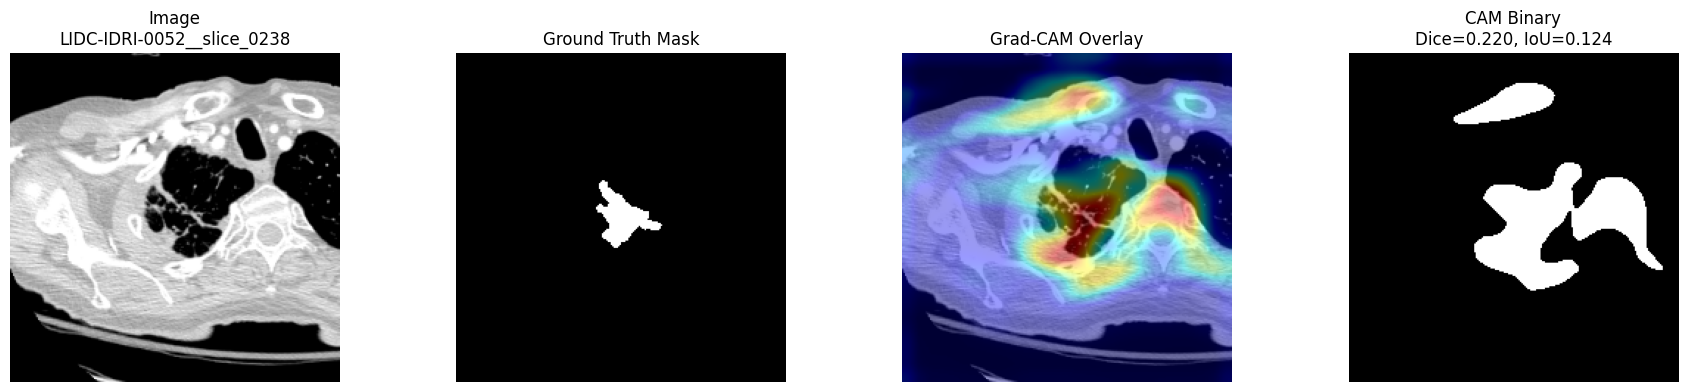

Threshold: 0.5 Max CAM: 1.0


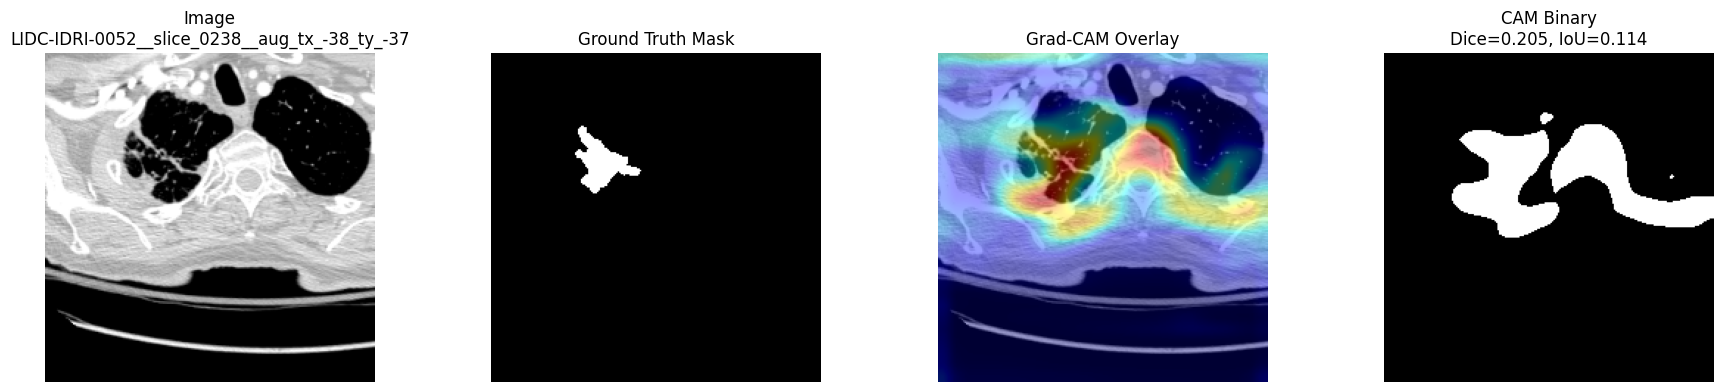

Threshold: 0.5 Max CAM: 1.0


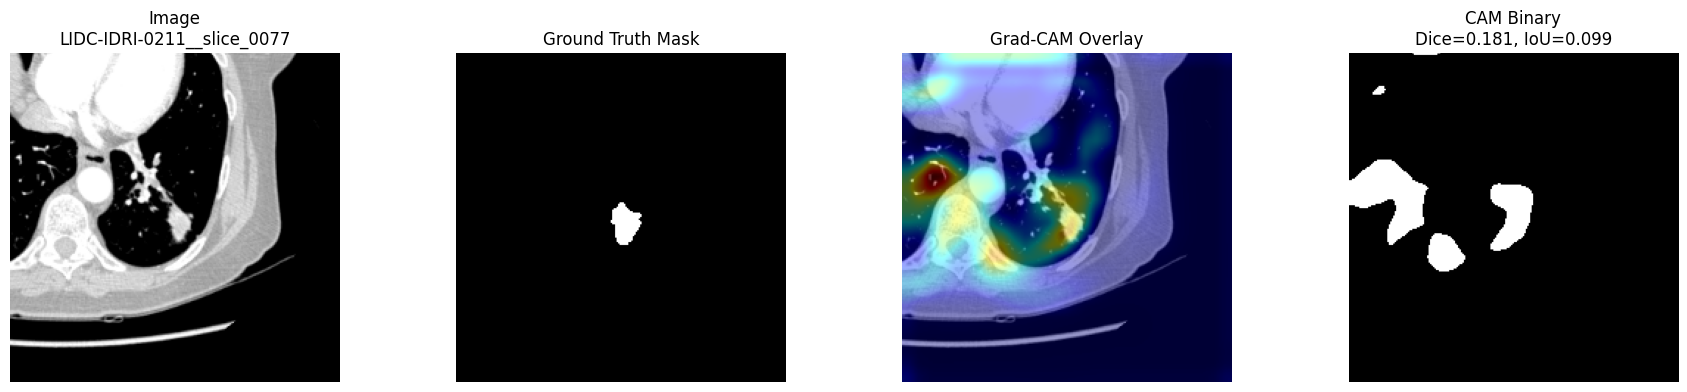

Threshold: 0.5 Max CAM: 1.0


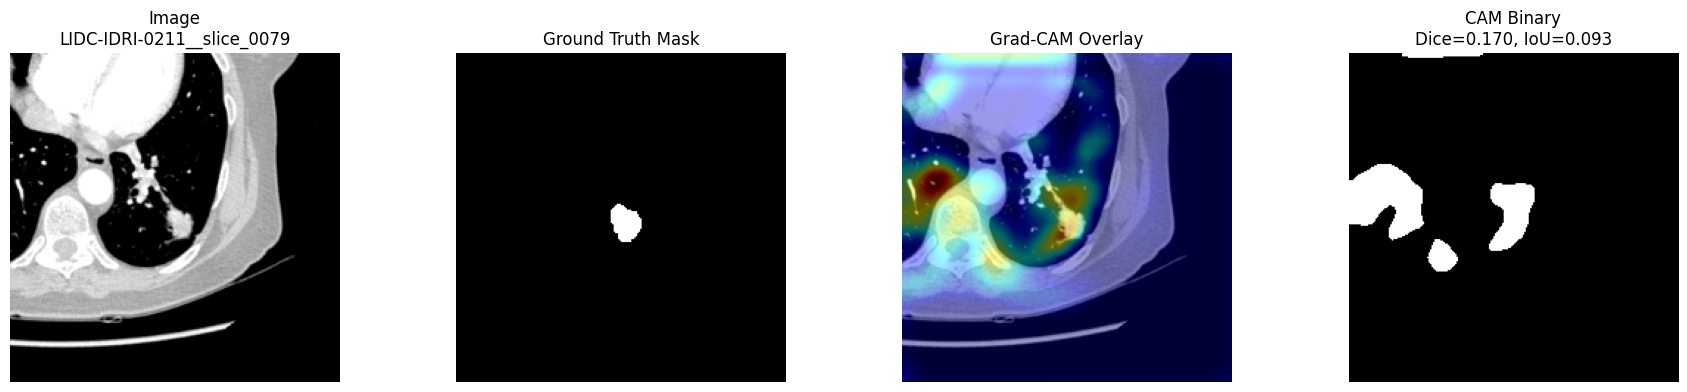

Threshold: 0.5 Max CAM: 1.0


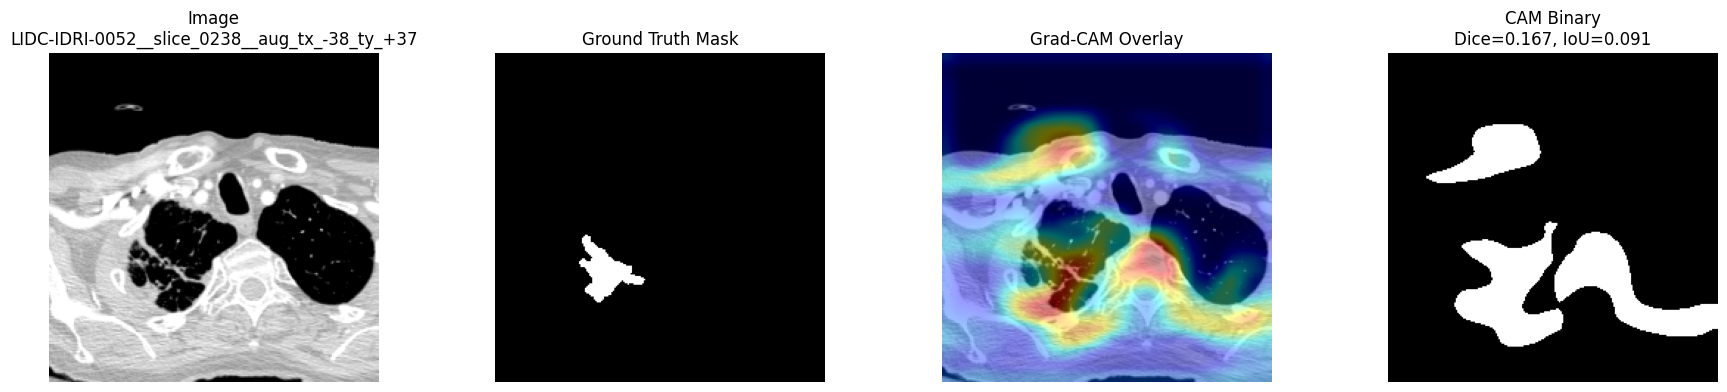

In [53]:
# ---------------------------
# VISUALIZE SAMPLE RESULTS
# ---------------------------
def overlay_cam_on_image(img: np.ndarray, cam: np.ndarray, alpha: float = 0.4):
    img_u8 = (img * 255).astype(np.uint8)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB)

    heatmap = (cam * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img_rgb, 1 - alpha, heatmap, alpha, 0)
    return overlay

def show_xai_examples(xai_df: pd.DataFrame, n: int = 5):
    if len(xai_df) == 0:
        print("No XAI results to show.")
        return

    sample_df = xai_df.sort_values("dice", ascending=False).head(n)

    gradcam_vis = GradCAMPlusPlus(best_model, best_model.get_last_conv_layer())

    for _, row in sample_df.iterrows():
        image_id = row["image_id"]
        img = np.load(row["image_path"]).astype(np.float32)
        if img.max() > 1.0 or img.min() < 0.0:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        gt_mask = load_mask(row["mask_path"], image_size=IMG_SIZE)

        input_tensor = torch.tensor(img[None, None, :, :], dtype=torch.float32, device=device)
        cam = gradcam_vis.generate(input_tensor, class_idx=TARGET_CLASS)
        cam_bin = binarize_cam(cam)
        overlay = overlay_cam_on_image(img, cam)

        fig, axes = plt.subplots(1, 4, figsize=(18, 4))

        axes[0].imshow(img, cmap="gray")
        axes[0].set_title(f"Image\n{image_id}")
        axes[0].axis("off")

        axes[1].imshow(gt_mask, cmap="gray")
        axes[1].set_title("Ground Truth Mask")
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Grad-CAM Overlay")
        axes[2].axis("off")

        axes[3].imshow(cam_bin, cmap="gray")
        axes[3].set_title(
            f"CAM Binary\nDice={row['dice']:.3f}, IoU={row['iou']:.3f}"
        )
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()

    gradcam_vis.remove_hooks()

show_xai_examples(xai_results_df, n=5)

Threshold: 0.5 Max CAM: 0.99999547


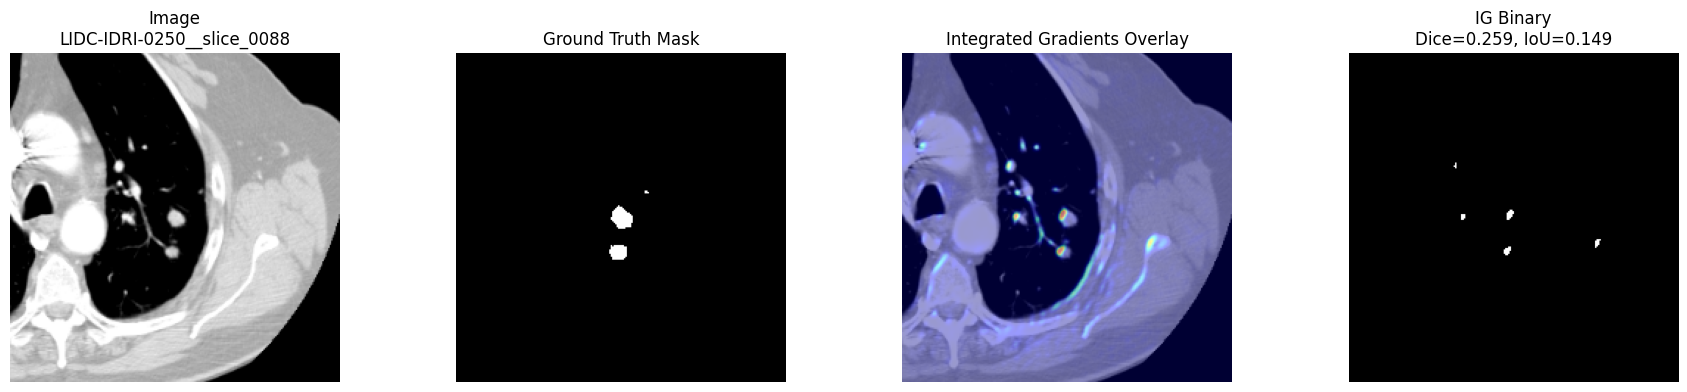

Threshold: 0.5 Max CAM: 0.9999933


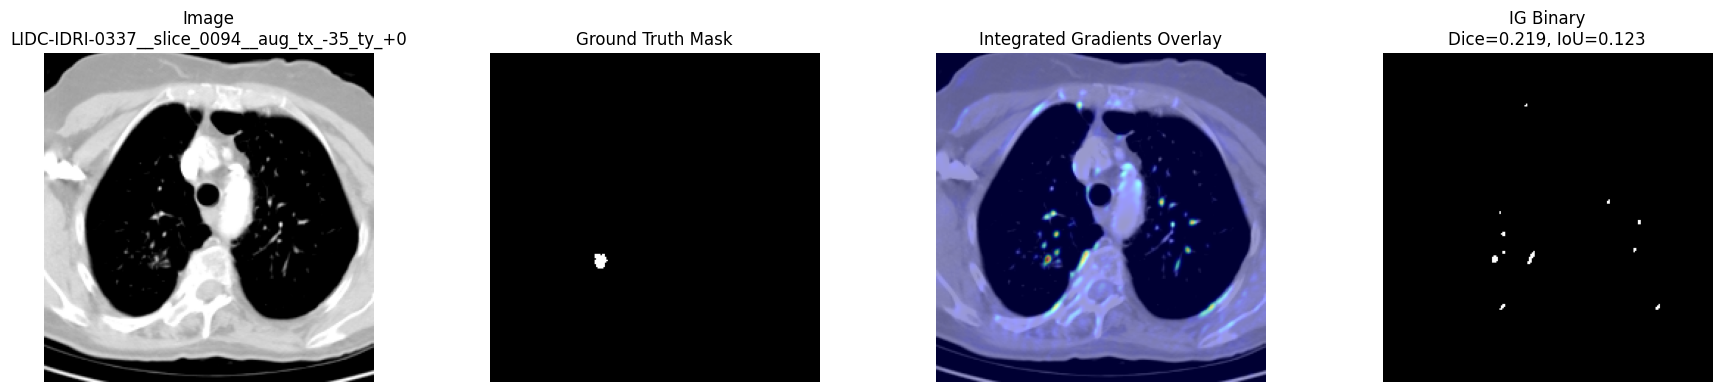

Threshold: 0.5 Max CAM: 0.9999971


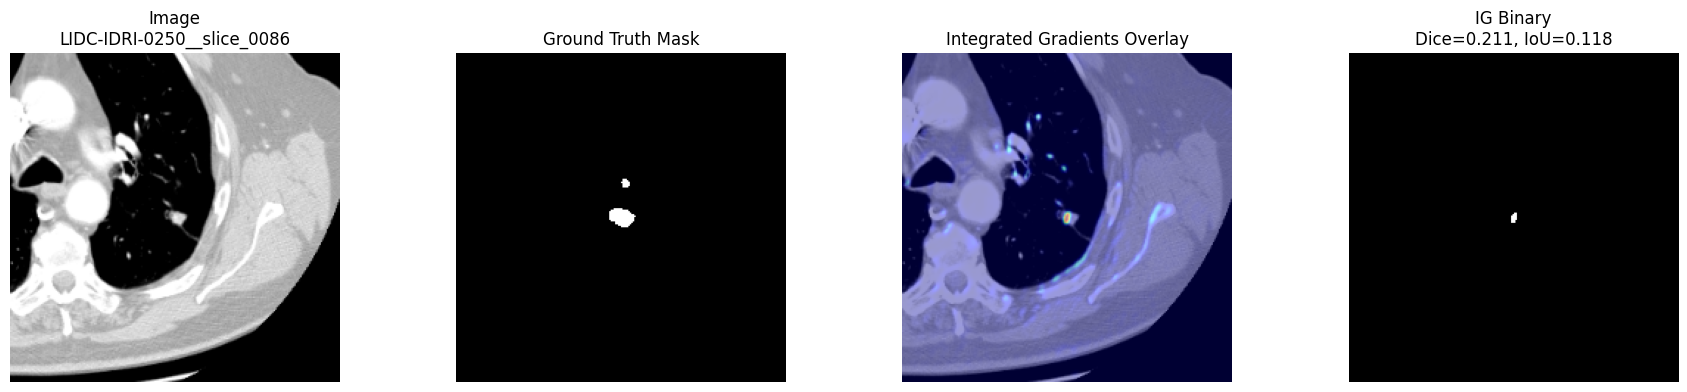

Threshold: 0.5 Max CAM: 0.9999934


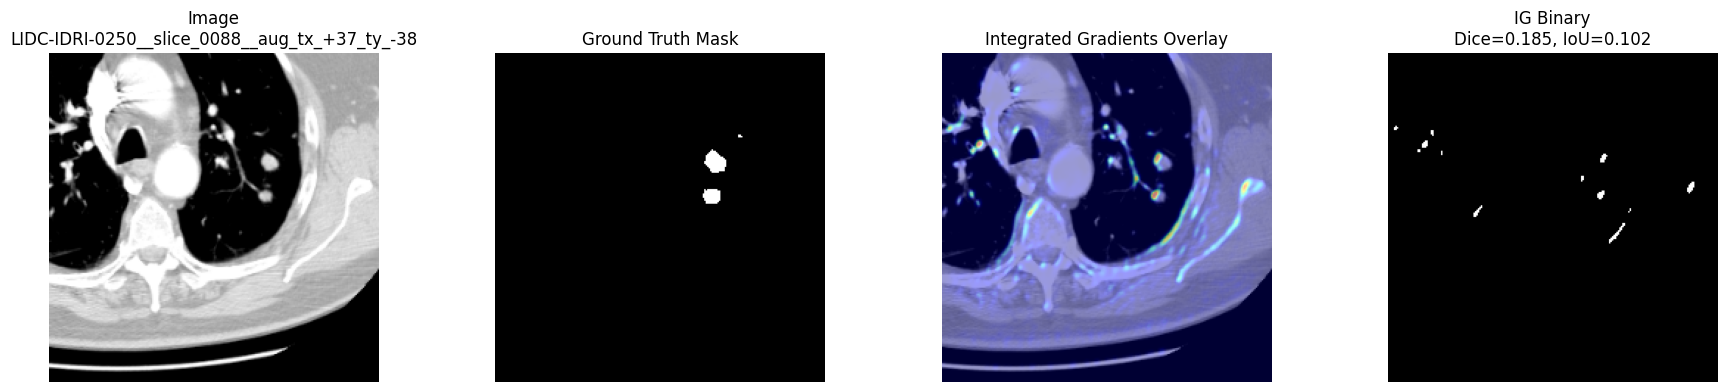

Threshold: 0.5 Max CAM: 0.99999493


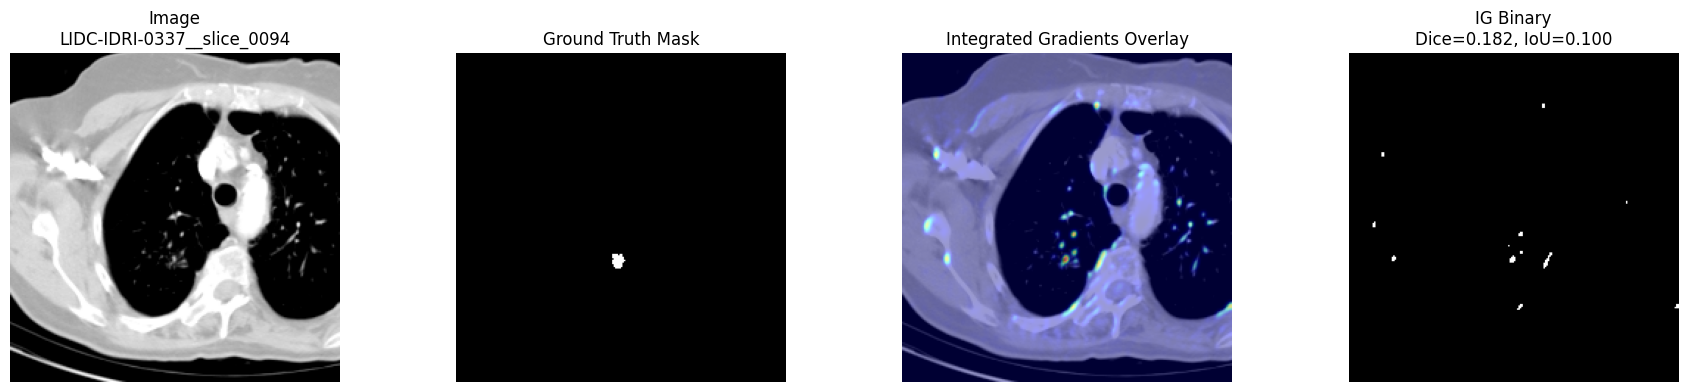

In [54]:

# ---------------------------
# [IG CHANGE] VISUALIZE SAMPLE INTEGRATED GRADIENTS RESULTS
# Added separately so Grad-CAM visualization remains unchanged
# ---------------------------
def show_ig_examples(ig_df: pd.DataFrame, n: int = 5):
    if len(ig_df) == 0:
        print("No Integrated Gradients results to show.")
        return

    sample_df = ig_df.sort_values("dice", ascending=False).head(n)
    ig_vis = IntegratedGradientsExplainer(best_model)

    for _, row in sample_df.iterrows():
        image_id = row["image_id"]
        img = np.load(row["image_path"]).astype(np.float32)
        if img.max() > 1.0 or img.min() < 0.0:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        gt_mask = load_mask(row["mask_path"], image_size=IMG_SIZE)

        input_tensor = torch.tensor(img[None, None, :, :], dtype=torch.float32, device=device)
        baseline = torch.zeros_like(input_tensor)

        ig_map = ig_vis.generate(
            input_tensor=input_tensor,
            class_idx=TARGET_CLASS,
            baseline=baseline,
            steps=IG_STEPS,
        )

        ig_bin = binarize_cam(ig_map)
        overlay = overlay_cam_on_image(img, ig_map)

        fig, axes = plt.subplots(1, 4, figsize=(18, 4))

        axes[0].imshow(img, cmap="gray")
        axes[0].set_title(f"Image\n{image_id}")
        axes[0].axis("off")

        axes[1].imshow(gt_mask, cmap="gray")
        axes[1].set_title("Ground Truth Mask")
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Integrated Gradients Overlay")
        axes[2].axis("off")

        axes[3].imshow(ig_bin, cmap="gray")
        axes[3].set_title(
            f"IG Binary\nDice={row['dice']:.3f}, IoU={row['iou']:.3f}"
        )
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()

show_ig_examples(ig_results_df, n=5)
